In [68]:
%matplotlib widget
%matplotlib widget
import os
from pathlib import Path
import time
import torch
import numpy as np
import math
import gc
from functools import partial
from dataset import Dataset, load_dataframes_from_folder, reverse_normalization
from torch.utils.data import DataLoader
from transformer_zerostep import GPTConfig, GPT, warmup_cosine_lr
import argparse
import warnings
import matplotlib.pyplot as plt


# set figure parameters
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['axes.labelsize']=14
plt.rcParams['xtick.labelsize']=11
plt.rcParams['ytick.labelsize']=11
plt.rcParams['axes.grid']=True
plt.rcParams['axes.xmargin']=0

In [69]:
# Overall settings
out_dir = "C:/Users/81C3009S/OneDrive/Desktop/Tesi"

# model_name = "model_low_speed.pt"
# model_name = "model_high_speed.pt"
# model_name = "model_24h_trainval_orig.pt"
# model_name = "model_high_speed_4layers_test.pt"
# model_name = "model_4l.pt"
# model_name = "model_4l_seq.pt"
model_name = "model_4l_seq_03.pt"
distil_model_name = "model_4l_seq.pt"
# distil_model_name = "model_4l_seq_03.pt"
# distil_model_name = "model_4l_seq_07.pt"
# distil_model_name = "model_6l_seq_03.pt"

# model_name = "model_4l_seq_v2_moveserver.pt"
# distil_model_name = "model_4l_seq_v2_moveserver.pt"
# distil_model_name = "model_6l_seq_v2_moveserver.pt"
# model_name = "model_4l_seq_v2_classicval.pt"
# distil_model_name = "model_4l_seq_v2_classicval.pt"
# distil_model_name = "model_6l_seq_v2_classicval.pt"

current_path = os.getcwd().split("in-context-bldc")[0]
data_path = os.path.join(current_path,"in-context-bldc", "data")

# folder = "CL_experiments_double_sensor_low_speed_ekf_and_meta/final/inertia13_ki-0.0029-kp-3.0000"
folder = "CL_experiments_double_sensor_high_speed_ekf_and_meta/final/inertia13_ki-0.0061-kp-11.8427"
folder_path = os.path.join(data_path, folder)

# Compute settings
cuda_device = "cuda:0"
no_cuda = False
threads = 10
compile = False

# Configure compute
torch.set_num_threads(threads) 
use_cuda = not no_cuda and torch.cuda.is_available()
device_name  = cuda_device if use_cuda else "cpu"
device = torch.device(device_name)
device_type = 'cuda' if 'cuda' in device_name else 'cpu' # for later use in torch.autocast
torch.set_float32_matmul_precision("high")
print(torch.cuda.is_available())
# Create out dir
out_dir = Path(out_dir)
exp_data = torch.load(out_dir/model_name, map_location=device, weights_only=False)
distil_exp_data = torch.load(out_dir/distil_model_name, map_location=device, weights_only=False)
seq_len = exp_data["cfg"].seq_len
nx = exp_data["cfg"].nx
exp_data["iter_num"]
print(seq_len)
print(exp_data["iter_num"])
print(exp_data['best_val_loss'])
print(exp_data["cfg"])
print(exp_data["cfg"].lr)
print(exp_data["train_time"]/3600)


False
10
5849
0.13759123720228672
Namespace(model_dir='out', out_file='model_4l_seq_03', in_file='model_4l_seq_03', init_from='scratch', seed=42, log_wandb=False, nx=4, nu=5, ny=1, seq_len=10, mag_range=(0.5, 0.97), phase_range=(0.0, 1.5707963267948966), fixed_system=False, n_layer=4, n_head=4, n_embd=16, dropout=0, bias=False, batch_size=128, max_iters=9000, warmup_iters=5000, lr=1e-05, weight_decay=0.0, eval_interval=10, eval_iters=10, fixed_lr=False, threads=16, no_cuda=False, cuda_device='cuda:0', compile=False, beta1=0.9, beta2=0.95, block_size=10, lr_decay_iters=9000, min_lr=1.0000000000000002e-06, decay_lr=True, eval_batch_size=128)
1e-05
10.995361271897952


number of parameters: 0.01M
number of parameters: 0.01M


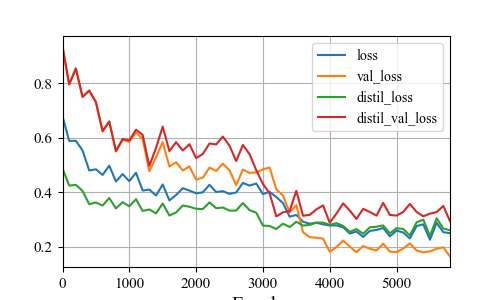

Model size in KB: 49.62890625
Distilled Model size in KB: 49.62890625


In [70]:
# generate the model
model_args = exp_data["model_args"]
gptconf = GPTConfig(**model_args)
model = GPT(gptconf).to(device)
# print(model.get_num_params())

distil_model_args = distil_exp_data["model_args"]
distil_gptconf = GPTConfig(**distil_model_args)
distil_model = GPT(distil_gptconf).to(device)

state_dict = exp_data["model"]
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    if k.startswith('module.'):
        state_dict[k[7:]] = v
        state_dict.pop(k)

model.load_state_dict(state_dict)

distil_state_dict = distil_exp_data["model"]
unwanted_prefix = '_orig_mod.'
for k,v in list(distil_state_dict.items()):
    if k.startswith(unwanted_prefix):
        distil_state_dict[k[len(unwanted_prefix):]] = distil_state_dict.pop(k)
    if k.startswith('module.'):
        distil_state_dict[k[7:]] = v
        distil_state_dict.pop(k)

model.load_state_dict(state_dict)
distil_model.load_state_dict(distil_state_dict)

#plot loss profile
plt.figure(figsize=(5,3))
plt.plot(np.arange(exp_data['iter_num'])[::100], exp_data['LOSS'][::100], label="loss")
plt.plot(np.arange(exp_data['iter_num'])[::100], exp_data['LOSS_VAL'][::100], label="val_loss")
plt.plot(np.arange(distil_exp_data['iter_num'])[::100], distil_exp_data['LOSS'][::100], label="distil_loss")
plt.plot(np.arange(distil_exp_data['iter_num'])[::100], distil_exp_data['LOSS_VAL'][::100], label="distil_val_loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()


# compute model size
size_in_bytes = sum(param.numel() * param.element_size() for param in model.parameters())
size_in_bytes += sum(buffer.numel() * buffer.element_size() for buffer in model.buffers())

# compute model size
distil_size_in_bytes = sum(param.numel() * param.element_size() for param in distil_model.parameters())
distil_size_in_bytes += sum(buffer.numel() * buffer.element_size() for buffer in distil_model.buffers())

# Convert bytes to kilobytes
size_in_kb = size_in_bytes / 1024
distil_size_in_kb = distil_size_in_bytes / 1024

print('Model size in KB:', size_in_kb)
print('Distilled Model size in KB:', distil_size_in_kb)

In [71]:
# assemble the data

dfs = load_dataframes_from_folder(folder_path)
# Log the number of DataFrames loaded
print(f"Loaded {len(dfs)} DataFrames from {folder_path}.") 
H = exp_data["cfg"].seq_len # context window length
# Create an instance of the dataset
dataset_exp = Dataset(dfs=dfs, seq_len=H)
dataloader = DataLoader(dataset_exp, batch_size=exp_data["cfg"].batch_size, shuffle=True)


Loaded 10 DataFrames from c:\Users\81C3009S\OneDrive\Desktop\Tesi\Python\GitHub\in-context-bldc\data\CL_experiments_double_sensor_high_speed_ekf_and_meta/final/inertia13_ki-0.0061-kp-11.8427.


In [72]:
## test each experiment
df_len = len(dfs)

rmse = np.zeros(df_len)
u_full_all = []
y_full_all = []

d_rmse = np.zeros(df_len)
d_u_full_all = []
d_y_full_all = []

# extract and stack all the experiments profiles
for i in range(df_len):
    u_full, y_full = dataset_exp.get_full_experiment(i)
    u_full, y_full = u_full.to(device), y_full.to(device)

    u_full_all.append(u_full)
    y_full_all.append(y_full)

u_full_all = torch.stack(u_full_all, dim=0)
y_full_all = torch.stack(y_full_all, dim=0)
y_pred_all = torch.zeros_like(y_full_all)

for i in range(df_len):
    d_u_full, d_y_full = dataset_exp.get_full_experiment(i)
    d_u_full, d_y_full = d_u_full.to(device), d_y_full.to(device)

    d_u_full_all.append(d_u_full)
    d_y_full_all.append(d_y_full)

d_u_full_all = torch.stack(d_u_full_all, dim=0)
d_y_full_all = torch.stack(d_y_full_all, dim=0)
d_y_pred_all = torch.zeros_like(y_full_all)

# generate the moving window of past estimations
last_omega = torch.zeros((df_len, H, 1)) 
d_last_omega = torch.zeros((df_len, H, 1)) 

with torch.no_grad():
    
    # j index moves aling the experiments time instants
    for j in range(y_full_all.shape[1]):
        
        # at time instant j
        # if the number of available samples < the context window, the model is fed only those samples
        if j < H:
            input_val = u_full_all[:, :j+1, :] # first j samples of the experiment
            input_val[:, :j+1, 4] = last_omega[:,-j-1:,0] # last j samples of the past estimations window

            pred = model(input_val)[:,-1,:] #we consider only the last value of the model estimation
        else:
            input_val = u_full_all[:,j-H+1:j+1, :]
            input_val[:,:, 4] = last_omega[:,:,0]

            pred = model(input_val)[:,-1,:] #we consider only the last value of the model estimation
        
        
        y_pred_all[:,j,0] = pred[:,0] # the list of estimations is updated
        last_omega = torch.roll(last_omega, -1, 1) # the window of last estimation is slid of 1 sample
        last_omega[:,-1,0] = y_pred_all[:,j,0] # last estimation is added to the window
        
    # input output and predictions are converted back to their original range of values
    u_full_all, y_full_all, y_pred_all  = reverse_normalization(u_full_all, y_full_all, y_pred_all)


with torch.no_grad():
    
    # j index moves aling the experiments time instants
    for j in range(d_y_full_all.shape[1]):
        
        # at time instant j
        # if the number of available samples < the context window, the model is fed only those samples
        if j < H:
            d_input_val = d_u_full_all[:, :j+1, :] # first j samples of the experiment
            d_input_val[:, :j+1, 4] = d_last_omega[:,-j-1:,0] # last j samples of the past estimations window

            d_pred = distil_model(d_input_val)[:,-1,:] #we consider only the last value of the model estimation
        else:
            d_input_val = d_u_full_all[:,j-H+1:j+1, :]
            d_input_val[:,:, 4] = d_last_omega[:,:,0]

            d_pred = distil_model(d_input_val)[:,-1,:] #we consider only the last value of the model estimation
        
        
        d_y_pred_all[:,j,0] = d_pred[:,0] # the list of estimations is updated
        d_last_omega = torch.roll(d_last_omega, -1, 1) # the window of last estimation is slid of 1 sample
        d_last_omega[:,-1,0] = d_y_pred_all[:,j,0] # last estimation is added to the window
        
    # input output and predictions are converted back to their original range of values
    d_u_full_all, d_y_full_all, d_y_pred_all  = reverse_normalization(d_u_full_all, d_y_full_all, d_y_pred_all)


In [73]:
# compute the rmse for each experiment, and produce its average
for i in range(df_len):
    y_tmp = y_full_all[i,:,:].cpu().numpy()
    y_pred_tmp = y_pred_all[i,:,:].cpu().numpy()
    rmse[i] = np.sqrt(((y_tmp-y_pred_tmp)**2).mean())

for i in range(df_len):
    d_y_tmp = d_y_full_all[i,:,:].cpu().numpy()
    # d_y_tmp = y_pred_all[i,:,:].cpu().numpy() # rmse calculated wrt teacher model
    d_y_pred_tmp = d_y_pred_all[i,:,:].cpu().numpy()
    d_rmse[i] = np.sqrt(((d_y_tmp-d_y_pred_tmp)**2).mean())
    

print("Average rmse original model: ", rmse.mean())
print("Average rmse distilled model: ", d_rmse.mean())
# print("Average rmse distilled model wrt teach model: ", d_rmse.mean())

Average rmse original model:  489.6004119873047
Average rmse distilled model:  742.2009033203125


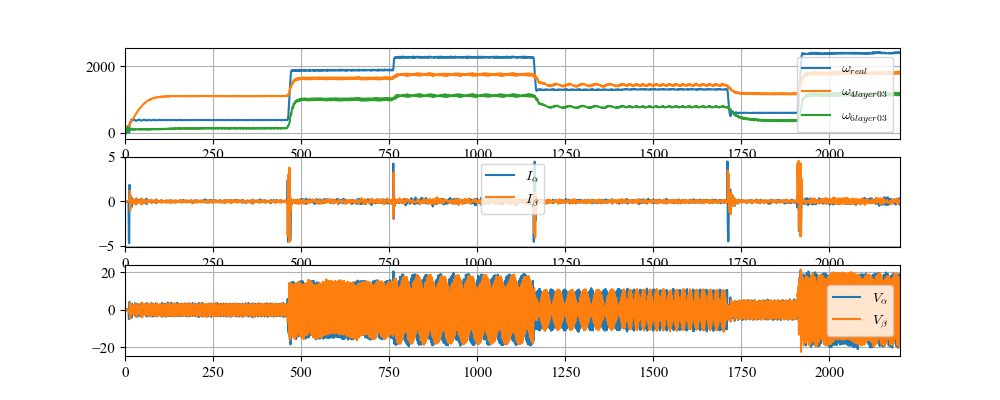

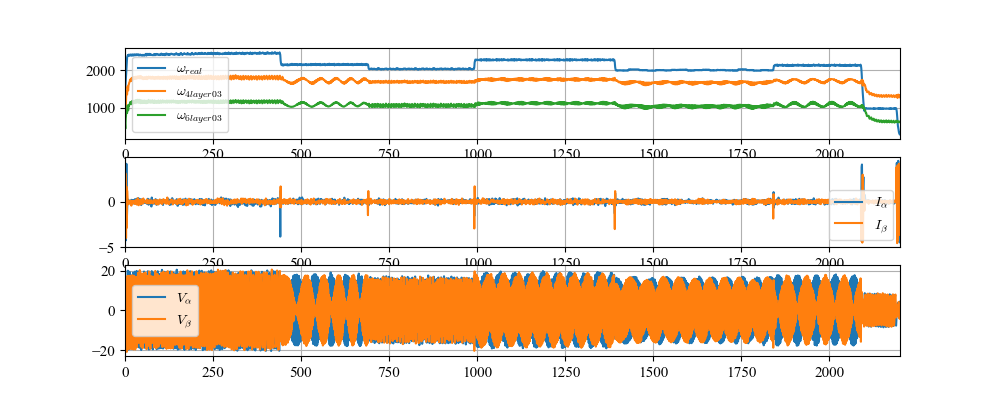

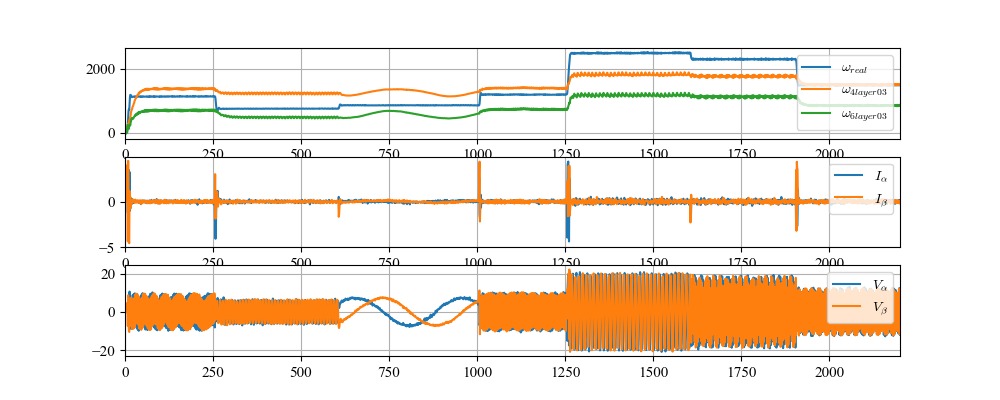

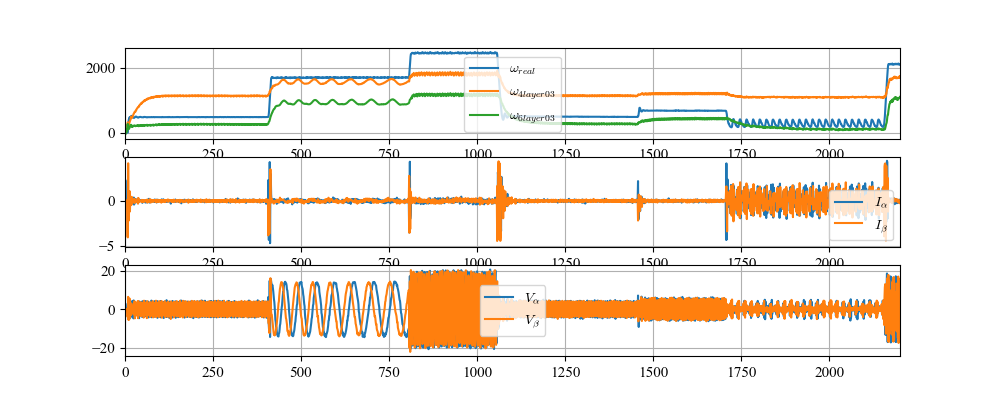

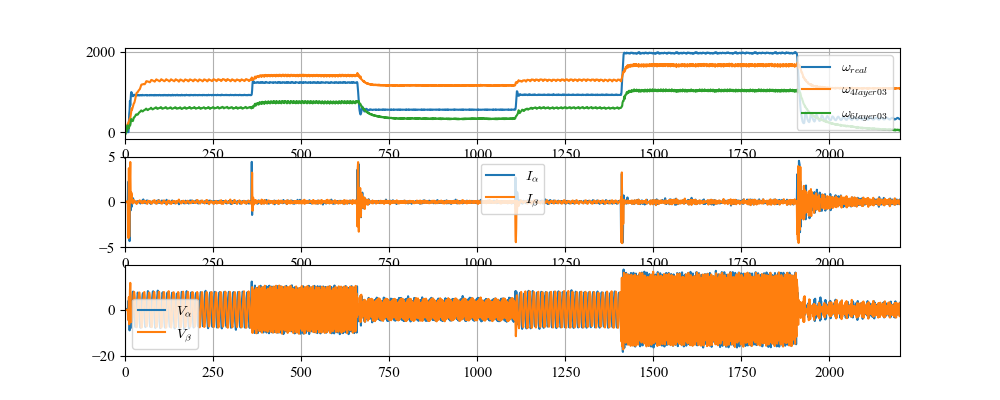

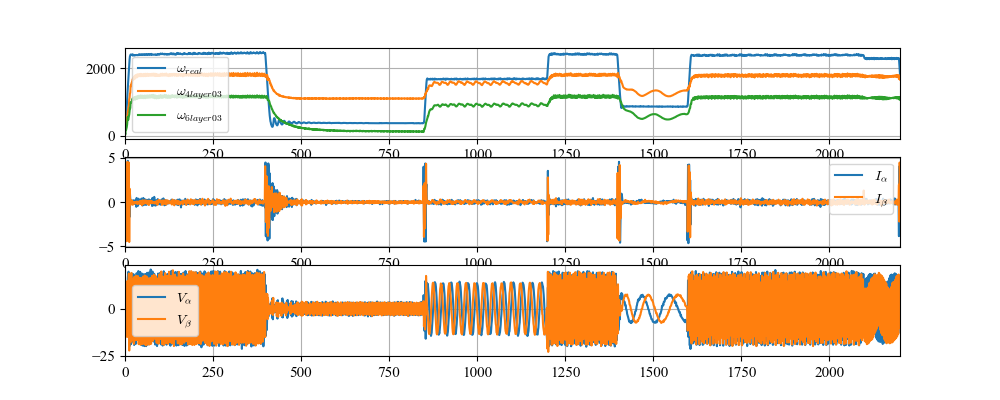

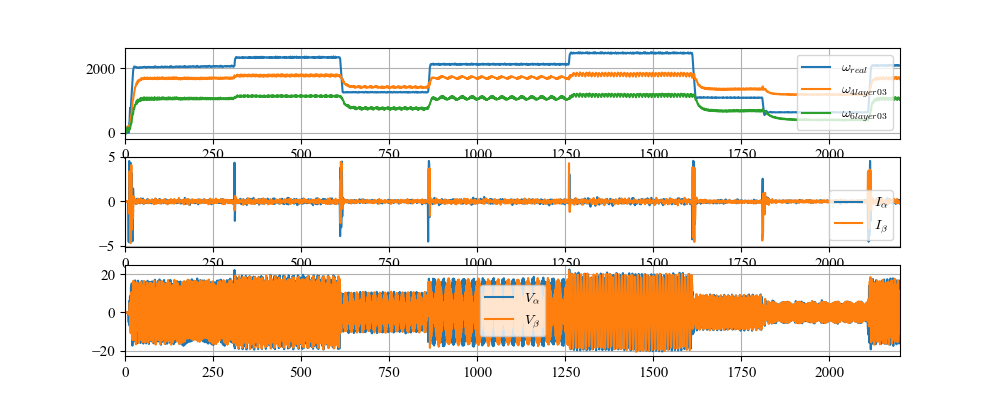

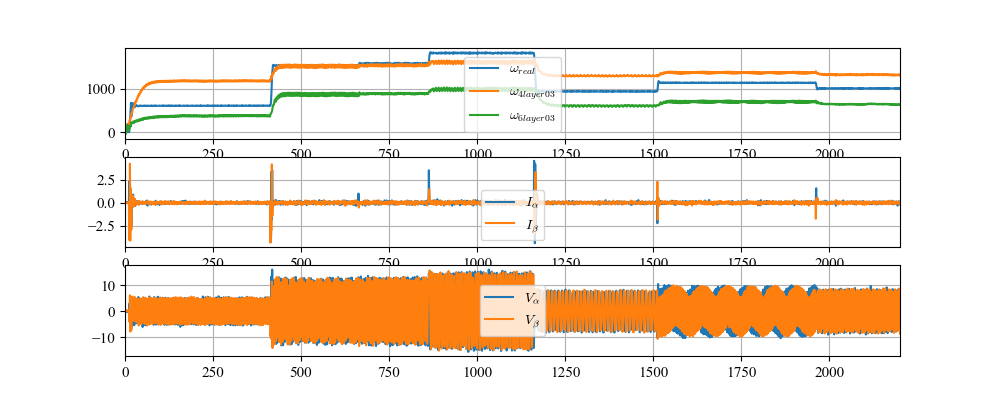

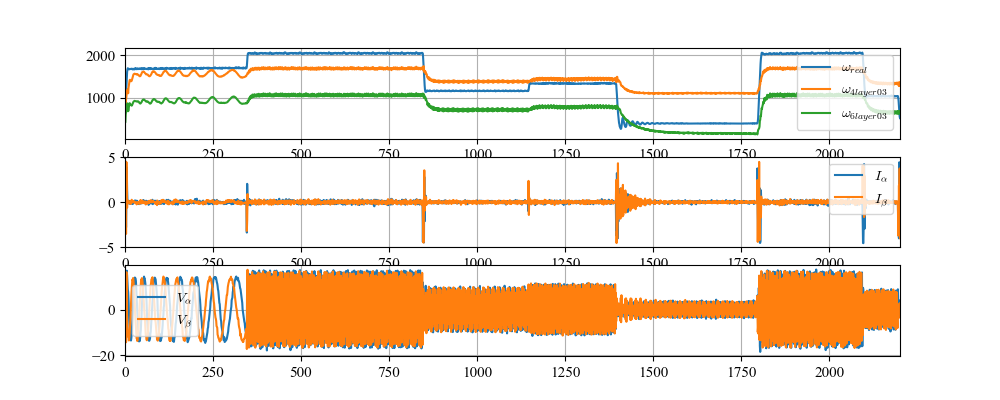

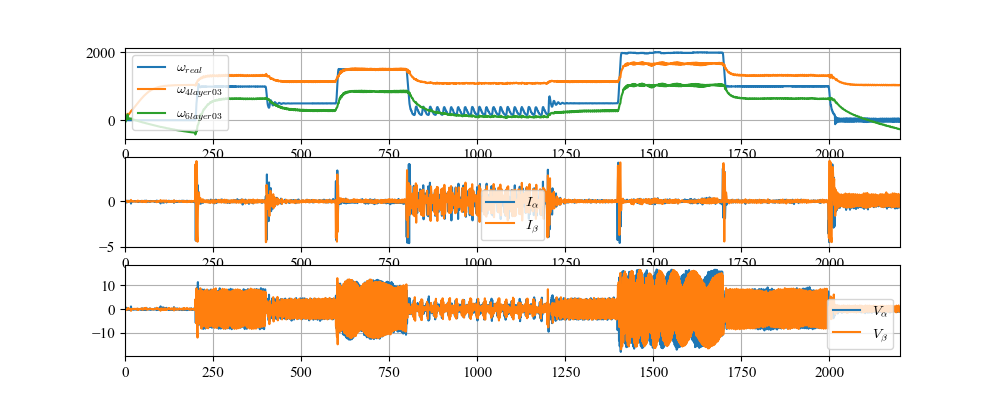

In [74]:
# os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# show the first 10 experiments
for i in range(10):

    y_full_np = y_full_all.cpu().numpy()
    y_pred_np = y_pred_all.cpu().numpy()
    u_full_np = u_full_all.cpu().numpy()

    d_y_pred_np = d_y_pred_all.cpu().numpy()

    # print(y_full_np.shape)
    # print(u_full_np.shape)
    fig = plt.figure(figsize=(10,4))
    ax1 = fig.add_subplot(3,1,1)
    ax1.plot(y_full_np[i])
    ax1.plot(y_pred_np[i])
    ax1.plot(d_y_pred_np[i])
    ax1.legend([r'$\omega_{real}$',r'$\omega_{4layer 03}$', r'$\omega_{6layer 03}$'])
    ax2 = fig.add_subplot(3,1,2)
    ax2.plot(u_full_np[i,:,0])
    ax2.plot(u_full_np[i,:,1])
    ax2.legend([r'$I_{\alpha}$',r'$I_{\beta}$'])
    ax3 = fig.add_subplot(3,1,3)
    ax3.plot(u_full_np[i,:,2])
    ax3.plot(u_full_np[i,:,3])
    ax3.legend([r'$V_{\alpha}$',r'$V_{\beta}$'])


    plt.show()
    